In [ ]:
!pip install split-folders

In [ ]:
# ==============================================================================
# LALUKAN INSTALASI PUSTAKA TERLEBIH DAHULU (JIKA BELUM)
# ==============================================================================

import os
import splitfolders
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

In [ ]:
# ==============================================================================
# 1. MOUNT GOOGLE DRIVE & PEMBAGIAN DATA ACAK
# ==============================================================================
# Menghubungkan notebook ke Google Drive Anda
drive.mount('/content/drive')

# GANTI PATH INI sesuai dengan lokasi folder dataset utama Anda di Google Drive
PATH_DATASET_DRIVE = '/content/drive/MyDrive/dataset_utama'
PATH_OUTPUT_SPLIT = '/content/dataset_split'

print("\n--- Memisahkan Dataset secara Acak (Train 80%, Val 10%, Test 10%) ---")
# seed=1337 mengunci pola keacakan agar konsisten saat run ulang
splitfolders.ratio(PATH_DATASET_DRIVE, output=PATH_OUTPUT_SPLIT,
                   seed=1337, ratio=(0.8, 0.1, 0.1), group_prefix=None, move=False)

train_dir = os.path.join(PATH_OUTPUT_SPLIT, 'train')
val_dir = os.path.join(PATH_OUTPUT_SPLIT, 'val')
test_dir = os.path.join(PATH_OUTPUT_SPLIT, 'test')

Mounted at /content/drive

--- Memisahkan Dataset secara Acak (Train 80%, Val 10%, Test 10%) ---


Copying files: 1100 files [03:15,  5.61 files/s]


In [ ]:
# ==============================================================================
# 2. DATA AUGMENTATION & DATA GENERATOR
# ==============================================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Augmentasi hanya untuk data training agar model tidak overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validasi dan testing hanya di-rescale nilainya (tidak boleh dimanipulasi/ditambah)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("\n--- Loading Data Gambar ke Generator ---")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes


--- Loading Data Gambar ke Generator ---
Found 880 images belonging to 2 classes.
Found 110 images belonging to 2 classes.
Found 110 images belonging to 2 classes.


In [ ]:
# ==============================================================================
# 3. MEMBANGUN ARSITEKTUR CNN (TRANSFER LEARNING MOBILENETV2)
# ==============================================================================
# Ekstraksi fitur dasar menggunakan bobot kecerdasan dari ImageNet
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Membekukan layer dasar agar tidak berubah selama training awal

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),            # Dropout untuk mengantisipasi data yang sedikit (1100 citra)
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,722 (9.24 MB)

 Trainable params: 164,482 (642.51 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [ ]:
# ==============================================================================
# 4. CALLBACKS & PROSES TRAINING MODEL
# ==============================================================================
# Menghentikan pelatihan lebih awal jika loss validation stagnan selama 5 epoch
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Menurunkan lr jika performa model mulai mendatar/stagnan
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

EPOCHS = 25

print("\n--- Memulai Proses Training Model ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)


--- Memulai Proses Training Model ---
Epoch 1/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 218s 8s/step - accuracy: 0.5375 - loss: 0.9877 - val_accuracy: 0.6455 - val_loss: 0.7048 - learning_rate: 1.0000e-04
Epoch 2/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 202s 7s/step - accuracy: 0.7261 - loss: 0.5597 - val_accuracy: 0.7364 - val_loss: 0.5019 - learning_rate: 1.0000e-04
Epoch 3/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 194s 7s/step - accuracy: 0.8148 - loss: 0.3855 - val_accuracy: 0.7909 - val_loss: 0.3607 - learning_rate: 1.0000e-04
Epoch 4/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 191s 7s/step - accuracy: 0.8580 - loss: 0.3424 - val_accuracy: 0.8909 - val_loss: 0.2248 - learning_rate: 1.0000e-04
Epoch 5/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 207s 7s/step - accuracy: 0.8898 - loss: 0.2848 - val_accuracy: 0.9273 - val_loss: 0.1749 - learning_rate: 1.0000e-04
Epoch 6/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 191s 7s/step - accuracy: 0.8807 - loss: 0.2657 - val_accuracy: 0.9364 - val_loss: 0.1446 - learning_rate: 1.0000e-04
Epoch 7/25
28/28 ━━━━━━━━━━━━━━

In [ ]:
# ==============================================================================
# 5. EVALUASI GLOBAL MENGGUNAKAN DATA TESTING
# ==============================================================================
print("\n--- Evaluasi Menggunakan Data Testing ---")
test_loss, test_acc = model.evaluate(test_generator)
print("Akurasi Data Testing: {:.2f}%".format(test_acc * 100))

# Menyimpan bobot model terbaik jika target akurasi terpenuhi
if test_acc >= 0.90:
    model.save('model_cnn_90persen.h5')
    print("Sukses: Model dengan akurasi >= 90% berhasil disimpan!")


--- Evaluasi Menggunakan Data Testing ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.9818 - loss: 0.0439


Akurasi Data Testing: 98.18%
Sukses: Model dengan akurasi >= 90% berhasil disimpan!



--- Menghitung Prediksi Detail ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step

              CLASSIFICATION REPORT
              precision    recall  f1-score   support

       segar       1.00      0.96      0.98        55
 tidak_segar       0.96      1.00      0.98        55

    accuracy                           0.98       110
   macro avg       0.98      0.98      0.98       110
weighted avg       0.98      0.98      0.98       110



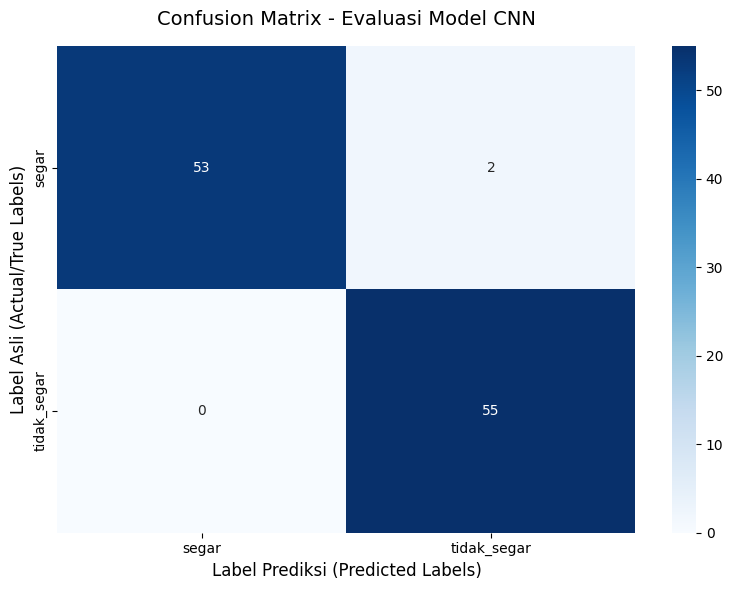

In [ ]:
# ==============================================================================
# 6. EVALUASI DETAIL: CLASSIFICATION REPORT & CONFUSION MATRIX
# ==============================================================================
print("\n--- Menghitung Prediksi Detail ---")
test_generator.reset()  # Reset pointer generator ke awal

# Memprediksi probabilitas data uji
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1) # Kelas hasil prediksi
y_true = test_generator.classes        # Kelas asli yang sebenarnya

class_labels = list(test_generator.class_indices.keys())

# Tampilan Text: Classification Report
print("\n" + "="*50)
print("              CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_labels))
print("="*50)

# Tampilan Visual: Confusion Matrix Diagram
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title('Confusion Matrix - Evaluasi Model CNN', fontsize=14, pad=15)
plt.ylabel('Label Asli (Actual/True Labels)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted Labels)', fontsize=12)
plt.tight_layout()
plt.show()


--- Menampilkan Grafik Performa Training ---


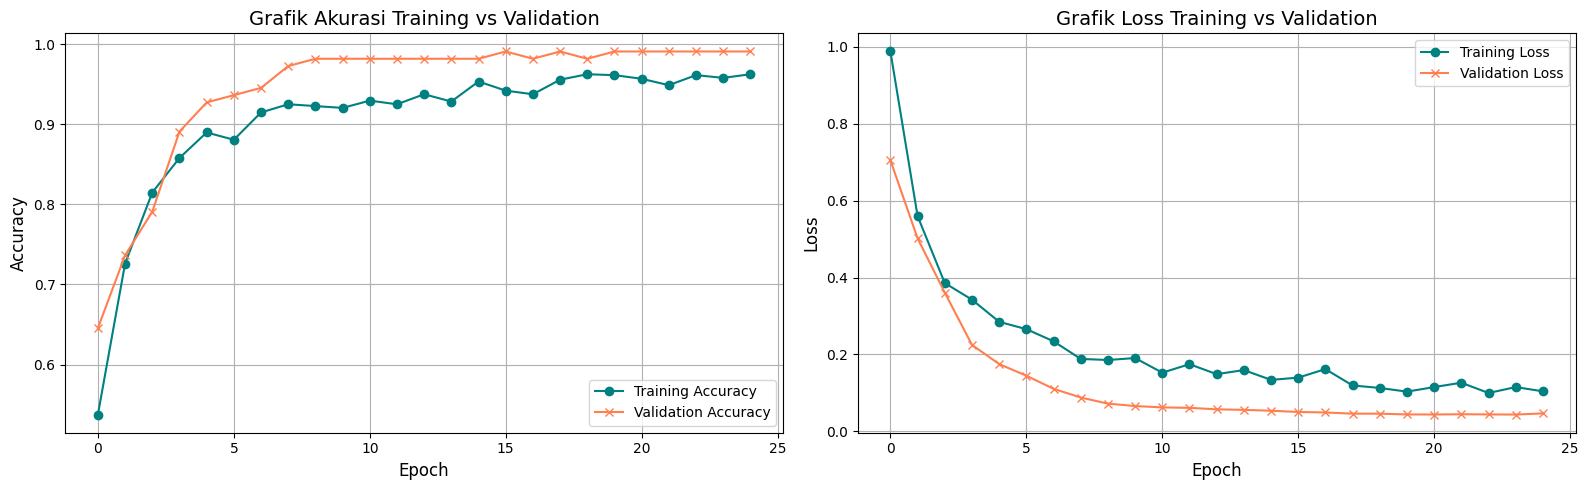

In [ ]:
# ==============================================================================
# 7. TAMPILAN GRAFIK AKURASI & LOSS (TRAINING VS VALIDATION)
# ==============================================================================
print("\n--- Menampilkan Grafik Performa Training ---")

# Mengambil data dari objek history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc)) # Menyesuaikan jumlah epoch yang berjalan

# Membuat canvas subplots (1 baris, 2 kolom)
plt.figure(figsize=(16, 5))

# --- GRAFIK 1: AKURASI ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='teal', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='coral', marker='x')
plt.title('Grafik Akurasi Training vs Validation', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True)
plt.legend(loc='lower right')

# --- GRAFIK 2: LOSS ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='teal', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='coral', marker='x')
plt.title('Grafik Loss Training vs Validation', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True)
plt.legend(loc='upper right')

# Memperapi tata letak grafik
plt.tight_layout()
plt.show()

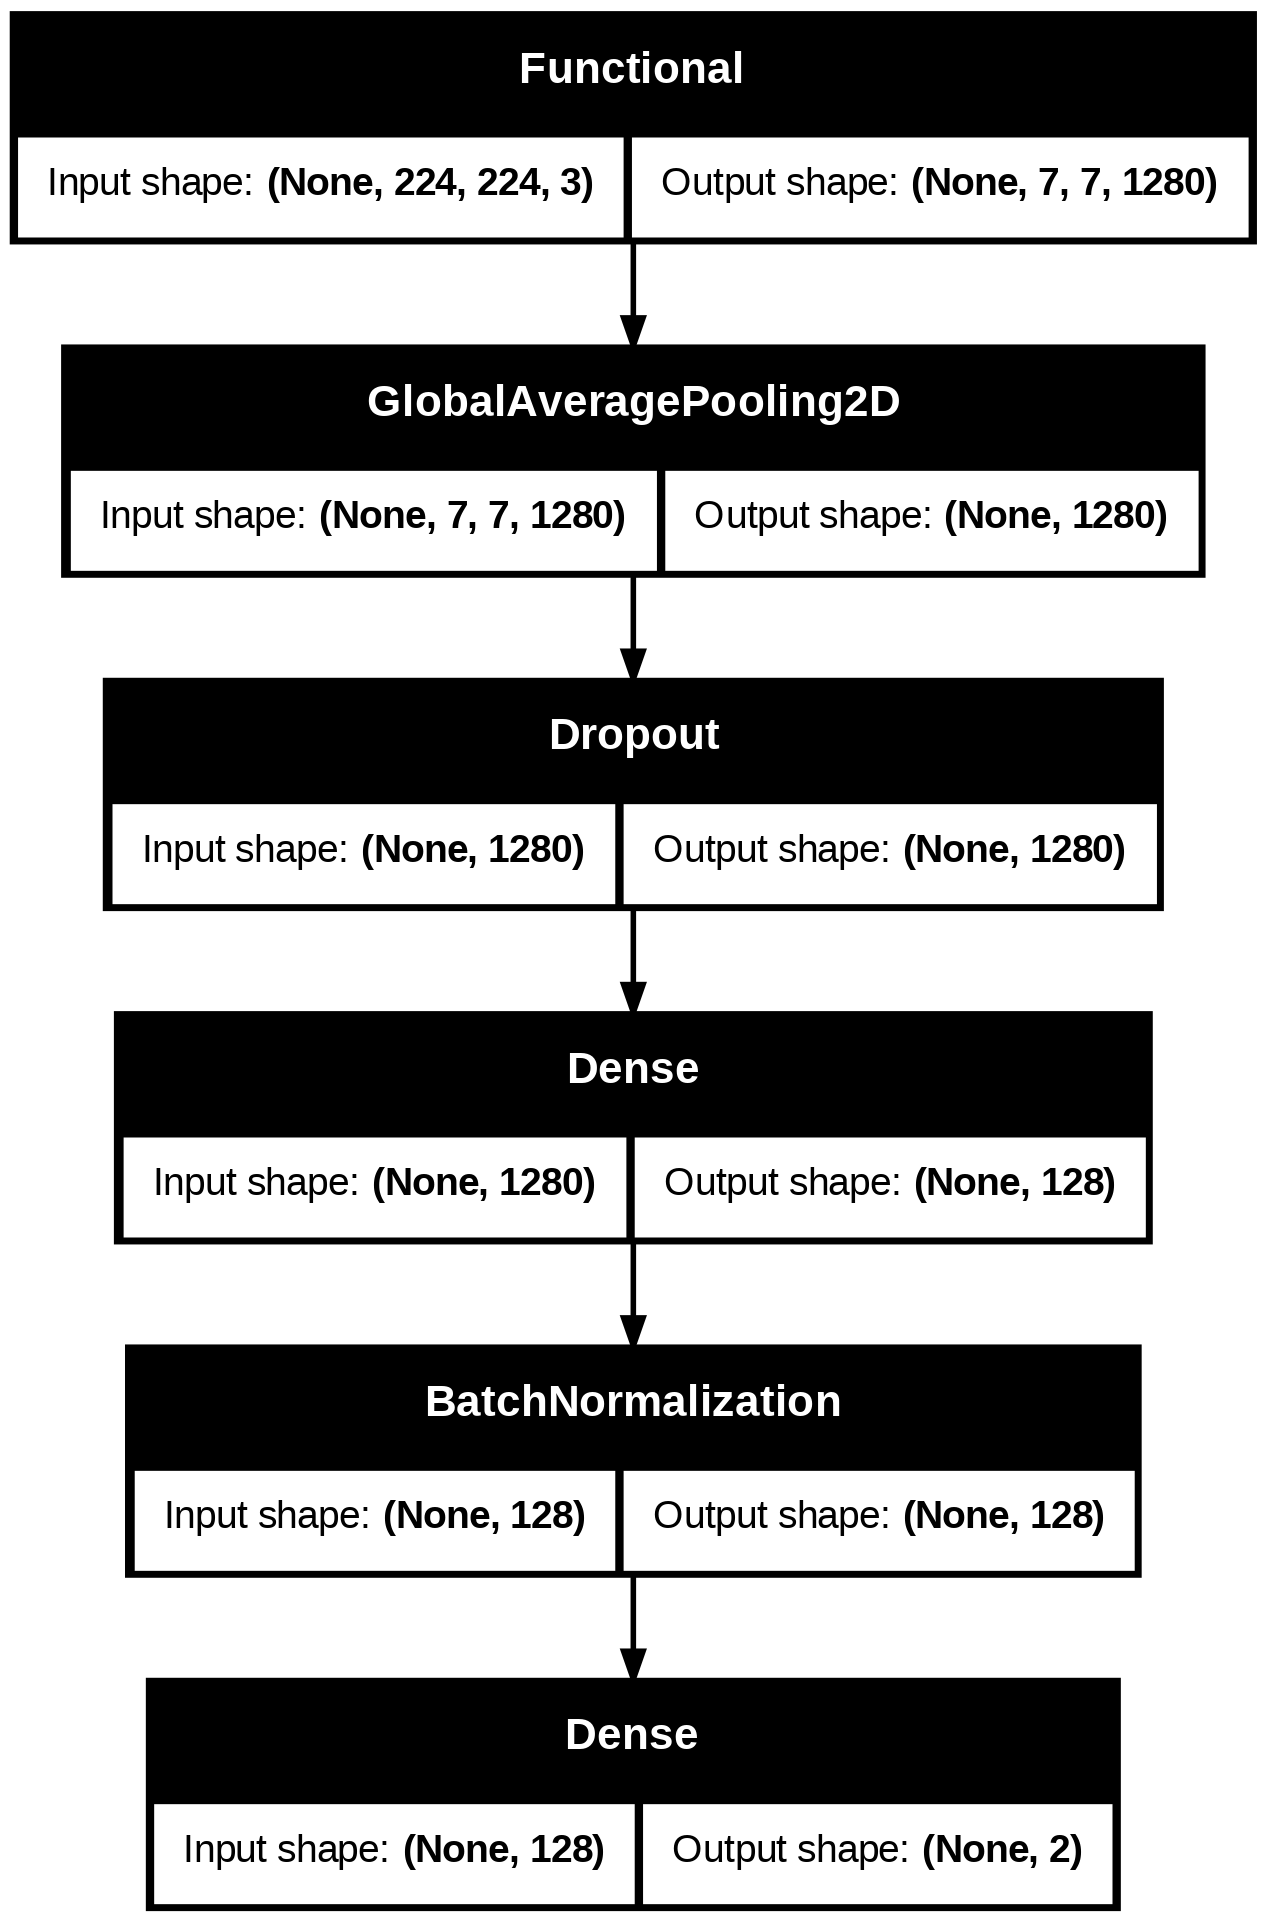

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_architecture.png', show_shapes=True)